# Para onde vai o dinheiro do ambulatório: oncologia, diálise e o resto

**A pergunta:** o SUS realiza milhões de procedimentos ambulatoriais por mês.
A intuição diz que o gasto acompanha o volume — mais consultas, mais dinheiro.
Não é o que acontece. Um punhado de procedimentos caros consome mais que
milhões de atendimentos simples, e é exatamente aí que se decide o orçamento
de uma secretaria de saúde.

**Fonte:** Sistema de Informações Ambulatoriais (SIA/SUS).

**Tempo estimado:** 5 a 10 minutos — o arquivo mensal passa de três milhões de
linhas.

**O que você leva daqui:** a leitura do código de procedimento do SIGTAP, a
separação entre volume e custo por nível de complexidade, o retrato da
oncologia e da terapia renal — e a medida de quanto as pessoas precisam sair
do próprio município para se tratar.

In [2]:
%pip install pysus nest_asyncio duckdb -q

Note: you may need to restart the kernel to use updated packages.


In [3]:
import nest_asyncio
nest_asyncio.apply()

import os
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 40)
con = duckdb.connect()

def mil(numero):
    "Número no padrão brasileiro: 1234567 vira 1.234.567."
    return f"{numero:,.0f}".replace(",", ".")

def reais(valor):
    "Valor em reais, com separador de milhar."
    return "R$ " + f"{valor:,.2f}".replace(",", "@").replace(".", ",").replace("@", ".")

print("Ambiente pronto.")

Ambiente pronto.


## 1. O que você pode trocar

In [4]:
UF = "PR"
ANO = 2024
MES = 6

print(f"{UF}, competência {MES:02d}/{ANO}")

PR, competência 06/2024


## 2. O SIA também é vários arquivos

Como o CNES, o SIA se divide em grupos. O principal é o **PA — Produção
Ambulatorial**, que traz a produção consolidada. Os demais são as APAC
(autorizações de procedimento de alta complexidade), cada uma com campos
próprios: quimioterapia, radioterapia, nefrologia, medicamentos.

In [5]:
from pysus import list_files, sia

GRUPOS_SIA = {
    "PA": "Produção ambulatorial — o arquivo principal",
    "AQ": "APAC de quimioterapia",
    "AR": "APAC de radioterapia",
    "AN": "APAC de nefrologia",
    "AM": "APAC de medicamentos",
    "AB": "APAC de cirurgia bariátrica",
    "ABO": "APAC de acompanhamento pós-bariátrica",
    "ACF": "APAC de confecção de fístula",
    "AD": "APAC de laudos diversos",
    "ATD": "APAC de tratamento dialítico",
    "AMP": "APAC de acompanhamento multiprofissional",
    "PS": "RAAS psicossocial",
    "SAD": "RAAS de atenção domiciliar",
    "BI": "Boletim de produção individualizada",
}

catalogo = list_files(dataset="sia", state=UF, year=ANO)
catalogo["arquivo"] = [os.path.basename(str(n).replace("\\", "/"))
                       for n in catalogo["name"]]
catalogo["grupo"] = catalogo["arquivo"].str.extract(r"^([A-Z]+?)" + UF)[0]

resumo = (catalogo.groupby("grupo").size().rename("arquivos no ano").to_frame())
resumo["o que traz"] = [GRUPOS_SIA.get(g, "") for g in resumo.index]
resumo.sort_values("arquivos no ano", ascending=False)

,arquivos no ano,o que traz
grupo,,
ABO,12,APAC de acompanhamento pós-bariátrica
ACF,12,APAC de confecção de fístula
AD,12,APAC de laudos diversos
AM,12,APAC de medicamentos
AMP,12,APAC de acompanhamento multiprofissional
AQ,12,APAC de quimioterapia
AR,12,APAC de radioterapia
ATD,12,APAC de tratamento dialítico
PA,12,Produção ambulatorial — o arquivo principal


In [6]:
caminhos = sia(UF, ANO, MES)
principal = [c for c in caminhos
             if os.path.basename(c).upper().startswith("PA")][0].replace("\\", "/")

linhas = con.execute(f"SELECT count(*) FROM read_parquet('{principal}')").fetchone()[0]
colunas = len(con.execute(f"DESCRIBE SELECT * FROM read_parquet('{principal}')").df())

print(f"Arquivo principal: {os.path.basename(principal)}")
print(f"{mil(linhas)} linhas e {colunas} colunas em UM ÚNICO MÊS.")
print()
print("Cada linha é um procedimento agregado por estabelecimento, competência,")
print("procedimento e características do paciente — não é um paciente por linha.")
print()
print("Carregar isso com pandas ocuparia perto de "
      f"{linhas * colunas * 40 / 1024**3:.0f} GB. Vamos de SQL.")

Arquivo principal: PAPR2406.parquet
3.700.738 linhas e 60 colunas em UM ÚNICO MÊS.
Cada linha é um procedimento agregado por estabelecimento, competência,
procedimento e características do paciente — não é um paciente por linha.
Carregar isso com pandas ocuparia perto de 8 GB. Vamos de SQL.


## 3. O código do procedimento não é aleatório

Todo procedimento do SUS tem um código de dez dígitos da tabela SIGTAP, e ele
é **estruturado**: os dois primeiros dígitos dizem o grupo, os quatro primeiros
dizem o subgrupo. Isso permite classificar milhões de linhas sem precisar de
uma tabela auxiliar.

In [7]:
GRUPOS_SIGTAP = {
    "01": "Promoção e prevenção",
    "02": "Procedimentos diagnósticos",
    "03": "Procedimentos clínicos",
    "04": "Procedimentos cirúrgicos",
    "05": "Transplantes",
    "06": "Medicamentos",
    "07": "Órteses, próteses e materiais",
    "08": "Ações complementares",
}

SUBGRUPOS = {
    "0301": "Consultas e atendimentos",
    "0302": "Fisioterapia",
    "0304": "Tratamento em oncologia",
    "0305": "Tratamento em nefrologia (diálise)",
    "0306": "Hemoterapia",
    "0202": "Laboratório clínico",
    "0204": "Radiologia",
    "0205": "Ultrassonografia",
    "0206": "Tomografia",
    "0207": "Ressonância magnética",
}

producao = con.execute(f"""
    SELECT substr(PA_PROC_ID, 1, 2) AS grupo,
           substr(PA_PROC_ID, 1, 4) AS subgrupo,
           sum(TRY_CAST(PA_QTDAPR AS BIGINT)) AS quantidade,
           count(*) AS registros,
           sum(TRY_CAST(PA_VALAPR AS DOUBLE)) AS valor
    FROM read_parquet('{principal}')
    GROUP BY 1, 2
""").df()

por_grupo = producao.groupby("grupo").agg(
    Registros=("registros", "sum"),
    Quantidade=("quantidade", "sum"),
    Valor=("valor", "sum"))
por_grupo.index = [f"{g} — {GRUPOS_SIGTAP.get(g, '?')}" for g in por_grupo.index]
por_grupo["% do valor"] = (por_grupo["Valor"] / por_grupo["Valor"].sum() * 100).round(1)
por_grupo["% dos registros"] = (
    por_grupo["Registros"] / por_grupo["Registros"].sum() * 100).round(1)

print(f"Valor total aprovado no mês: {reais(por_grupo['Valor'].sum())}\n")
por_grupo.sort_values("Valor", ascending=False)

Valor total aprovado no mês: R$ 155.858.942,05


,Registros,Quantidade,Valor,% do valor,% dos registros
03 — Procedimentos clínicos,1967400,7952729.0,7.311831e+07,46.9,53.2
02 — Procedimentos diagnósticos,1156227,6066381.0,5.011280e+07,32.2,31.2
06 — Medicamentos,410159,14445501.0,1.530685e+07,9.8,11.1
"07 — Órteses, próteses e materiais",19805,78943.0,6.772957e+06,4.3,0.5
04 — Procedimentos cirúrgicos,42975,79297.0,6.636081e+06,4.3,1.2
05 — Transplantes,10798,9793.0,3.170745e+06,2.0,0.3
08 — Ações complementares,35772,139079.0,7.194111e+05,0.5,1.0
01 — Promoção e prevenção,57602,1548341.0,2.178775e+04,0.0,1.6


## 4. Volume e dinheiro não andam juntos

Agora o gráfico que resume a economia do ambulatório. À esquerda, quantos
procedimentos; à direita, quanto custaram. As duas listas quase não se
parecem.

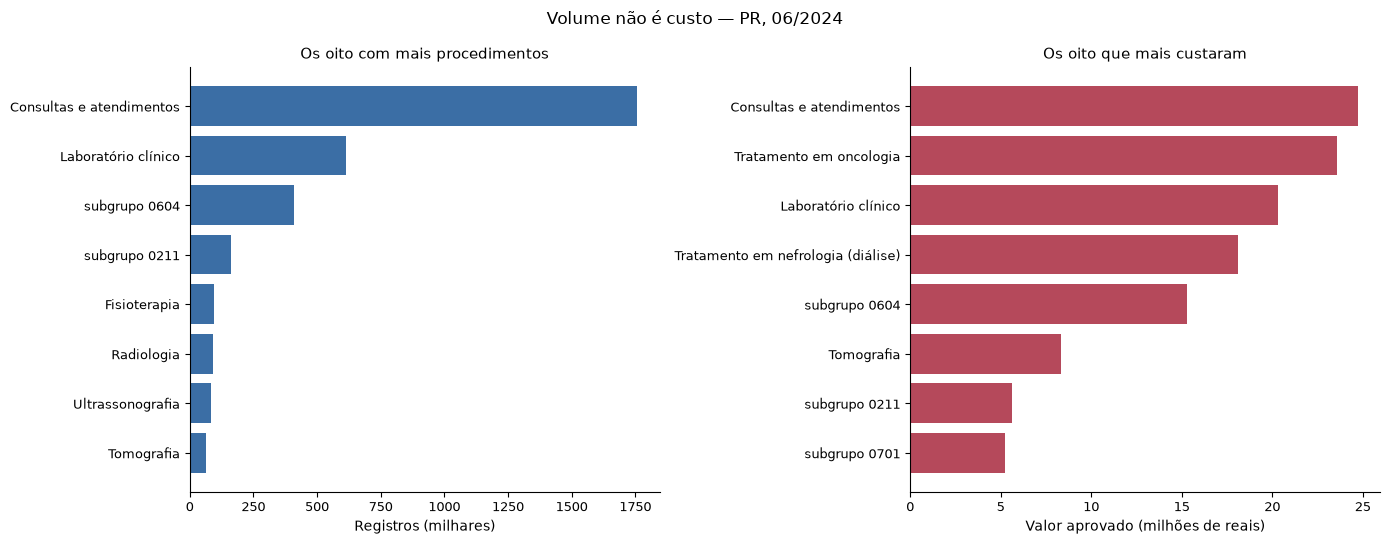

Custo médio por registro nos subgrupos mais caros:


,nome,Registros,Valor,Custo médio
subgrupo,,,,
0301,Consultas e atendimentos,1757094,2.471158e+07,14.06
0304,Tratamento em oncologia,33529,2.358829e+07,703.52
0202,Laboratório clínico,614993,2.029913e+07,33.01
0305,Tratamento em nefrologia (diálise),7514,1.809120e+07,2407.67
0604,subgrupo 0604,410159,1.530685e+07,37.32
0206,Tomografia,65495,8.334170e+06,127.25


In [8]:
por_subgrupo = producao.groupby("subgrupo").agg(
    Registros=("registros", "sum"), Valor=("valor", "sum"))
por_subgrupo["nome"] = [SUBGRUPOS.get(s, f"subgrupo {s}") for s in por_subgrupo.index]
por_subgrupo["Custo médio"] = (por_subgrupo["Valor"] / por_subgrupo["Registros"]).round(2)

top_volume = por_subgrupo.nlargest(8, "Registros").iloc[::-1]
top_valor = por_subgrupo.nlargest(8, "Valor").iloc[::-1]

figura, (eixo1, eixo2) = plt.subplots(1, 2, figsize=(14, 5.5))

eixo1.barh(top_volume["nome"], top_volume["Registros"] / 1000, color="#3b6ea5")
eixo1.set_xlabel("Registros (milhares)")
eixo1.set_title("Os oito com mais procedimentos", fontsize=11)

eixo2.barh(top_valor["nome"], top_valor["Valor"] / 1_000_000, color="#b5495b")
eixo2.set_xlabel("Valor aprovado (milhões de reais)")
eixo2.set_title("Os oito que mais custaram", fontsize=11)

for eixo in (eixo1, eixo2):
    eixo.spines[["top", "right"]].set_visible(False)
    eixo.tick_params(labelsize=9)

plt.suptitle(f"Volume não é custo — {UF}, {MES:02d}/{ANO}", fontsize=12)
plt.tight_layout()
plt.show()

print("Custo médio por registro nos subgrupos mais caros:\n")
por_subgrupo.nlargest(6, "Valor")[["nome", "Registros", "Valor", "Custo médio"]]

## 5. O nível de complexidade e a pegadinha do valor zero

O campo `PA_NIVCPL` classifica o procedimento em atenção básica, média e alta
complexidade. Ao somar o valor por nível, aparece algo que assusta quem vê pela
primeira vez: **a atenção básica custa quase nada.**

Não custa. Ela é paga por outro caminho — transferências por bloco de
financiamento, calculadas por população coberta, não por procedimento
realizado. O SIA registra o que foi feito, mas o valor aprovado dessas linhas
fica zerado. Somar valor do SIA e concluir que a atenção primária é barata é um
erro de leitura, não um achado.

In [9]:
NIVEIS = {"0": "Não se aplica", "1": "Atenção básica",
          "2": "Média complexidade", "3": "Alta complexidade"}

complexidade = con.execute(f"""
    SELECT PA_NIVCPL AS nivel,
           count(*) AS registros,
           sum(TRY_CAST(PA_QTDAPR AS BIGINT)) AS quantidade,
           sum(TRY_CAST(PA_VALAPR AS DOUBLE)) AS valor
    FROM read_parquet('{principal}')
    GROUP BY 1 ORDER BY 1
""").df()
complexidade["nível"] = [NIVEIS.get(n, n) for n in complexidade["nivel"]]
complexidade = complexidade.set_index("nível")
complexidade["% dos registros"] = (
    complexidade["registros"] / complexidade["registros"].sum() * 100).round(1)
complexidade["% do valor"] = (
    complexidade["valor"] / complexidade["valor"].sum() * 100).round(1)

complexidade[["registros", "% dos registros", "valor", "% do valor"]]

,registros,% dos registros,valor,% do valor
nível,,,,
Não se aplica,57789,1.6,7.492759e+06,4.8
Atenção básica,750809,20.3,9.400000e+01,0.0
Média complexidade,2329438,62.9,6.924999e+07,44.4
Alta complexidade,562702,15.2,7.911610e+07,50.8


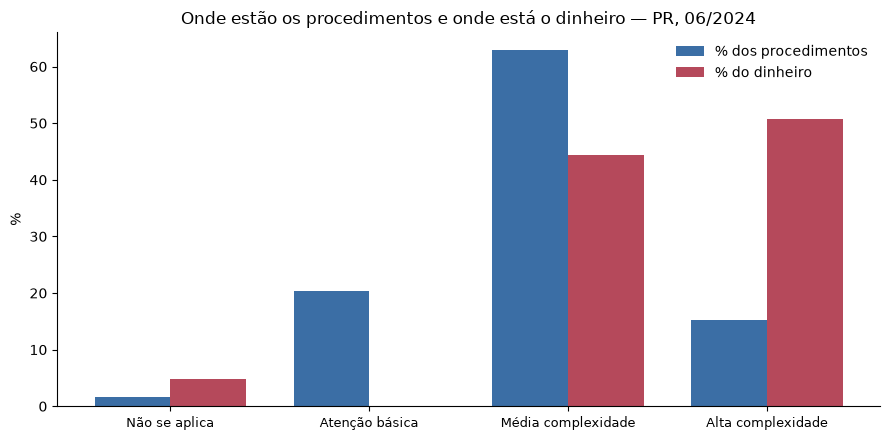

A alta complexidade é 15.2% dos procedimentos e 50.8% do valor aprovado.


In [10]:
figura, eixo = plt.subplots(figsize=(9, 4.5))
posicoes = range(len(complexidade))
largura = 0.38

eixo.bar([p - largura / 2 for p in posicoes], complexidade["% dos registros"],
         largura, label="% dos procedimentos", color="#3b6ea5")
eixo.bar([p + largura / 2 for p in posicoes], complexidade["% do valor"],
         largura, label="% do dinheiro", color="#b5495b")

eixo.set_xticks(list(posicoes))
eixo.set_xticklabels(complexidade.index, fontsize=9)
eixo.set_ylabel("%")
eixo.set_title(f"Onde estão os procedimentos e onde está o dinheiro — {UF}, {MES:02d}/{ANO}",
               fontsize=12)
eixo.legend(frameon=False)
eixo.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

alta = complexidade.loc["Alta complexidade"]
print(f"A alta complexidade é {alta['% dos registros']}% dos procedimentos "
      f"e {alta['% do valor']}% do valor aprovado.")

## 6. Oncologia e diálise: dois tratamentos que sustentam o gasto

São os dois subgrupos que melhor mostram por que a conta fecha assim. Ambos
são tratamentos **contínuos**: o registro não é uma consulta, é um mês de
tratamento autorizado.

In [11]:
def detalhe_subgrupo(codigo, nome):
    dados = con.execute(f"""
        SELECT PA_PROC_ID AS procedimento,
               count(*) AS registros,
               sum(TRY_CAST(PA_QTDAPR AS BIGINT)) AS quantidade,
               sum(TRY_CAST(PA_VALAPR AS DOUBLE)) AS valor
        FROM read_parquet('{principal}')
        WHERE substr(PA_PROC_ID, 1, 4) = '{codigo}'
        GROUP BY 1 ORDER BY valor DESC
    """).df()
    total = dados["valor"].sum()
    print(f"\n{nome} (subgrupo {codigo})")
    print(f"  procedimentos distintos: {len(dados)}")
    print(f"  registros no mês:        {mil(dados['registros'].sum())}")
    print(f"  valor aprovado:          {reais(total)}")
    print(f"  custo médio por registro:{reais(total / dados['registros'].sum()):>15}")
    return dados

oncologia = detalhe_subgrupo("0304", "Tratamento em oncologia")
nefrologia = detalhe_subgrupo("0305", "Tratamento em nefrologia")

Tratamento em oncologia (subgrupo 0304)


procedimentos distintos: 159
  registros no mês:        33.529
  valor aprovado:          R$ 23.588.288,58
  custo médio por registro:      R$ 703,52
Tratamento em nefrologia (subgrupo 0305)
  procedimentos distintos: 8
  registros no mês:        7.514
  valor aprovado:          R$ 18.091.199,40
  custo médio por registro:    R$ 2.407,67


In [12]:
pacientes_dialise = con.execute(f"""
    SELECT count(*) AS registros,
           sum(TRY_CAST(PA_QTDAPR AS BIGINT)) AS sessoes
    FROM read_parquet('{principal}')
    WHERE substr(PA_PROC_ID, 1, 4) = '0305'
""").df().iloc[0]

print("Terapia renal substitutiva\n")
print(f"Registros no mês:  {mil(pacientes_dialise['registros'])}")
print(f"Sessões somadas:   {mil(pacientes_dialise['sessoes'])}")
print()
print("Cada registro corresponde, em geral, a um mês de tratamento de uma")
print("pessoa — então o número de registros é uma ESTIMATIVA de quantas pessoas")
print("fazem diálise no estado. A célula seguinte confere essa estimativa contra")
print("a contagem direta, que vem de outro arquivo do próprio SIA.")

Terapia renal substitutiva
Registros no mês:  7.514
Sessões somadas:   73.891
Cada registro corresponde, em geral, a um mês de tratamento de uma
pessoa — então o número de registros é uma ESTIMATIVA de quantas pessoas
fazem diálise no estado. A célula seguinte confere essa estimativa contra
a contagem direta, que vem de outro arquivo do próprio SIA.


### Conferindo a estimativa

O número acima é uma estimativa tirada da produção agregada. Desde que o SIA
passou a ser lido por famílias de arquivo, dá para **conferir**: a APAC de
tratamento dialítico (`ATD`) tem uma linha por pessoa, com identificador do
paciente.

In [13]:
# A APAC de tratamento dialítico (prefixo ATD) traz uma linha por PESSOA,
# com identificador do paciente — dá para contar em vez de estimar.
# Selecionamos pelo prefixo do nome do arquivo: o parâmetro `group` da PySUS
# junta famílias diferentes sob o mesmo rótulo.
caminhos_atd = sia(UF, ANO, MES)
atd = [c.replace("\\", "/") for c in caminhos_atd
       if os.path.basename(c).upper().startswith("ATD")]

if not atd:
    print("Não há arquivo ATD neste recorte (a série começa em agosto de 2014).")
else:
    direto = con.execute(f"""
        SELECT count(*) AS apacs,
               count(DISTINCT AP_CNSPCN) AS pacientes
        FROM read_parquet('{atd[0]}')
    """).df().iloc[0]

    estimativa = int(pacientes_dialise["registros"])
    pacientes = int(direto["pacientes"])

    print("Estimativa x contagem direta, mesmo estado e mesmo mês\n")
    print(f"  produção (PA, subgrupo 0305): {mil(estimativa):>8} registros")
    print(f"  APAC de diálise (ATD):        {mil(pacientes):>8} pacientes distintos")
    print(f"\n  a estimativa fica {estimativa / pacientes:.2f}x a contagem real "
          f"({(estimativa / pacientes - 1) * 100:+.0f}%).")
    print("\nA aproximação é boa, mas não é a mesma coisa: um paciente pode ter")
    print("mais de um registro no mês. Quando a pergunta for sobre PESSOAS, use")
    print("o ATD — ele traz idade, sexo, exames, desfecho e o mesmo identificador")
    print("mês a mês. O notebook `dialise-o-caminho-do-paciente-renal.ipynb` faz isso.")

Estimativa x contagem direta, mesmo estado e mesmo mês
  produção (PA, subgrupo 0305):    7.514 registros
  APAC de diálise (ATD):           6.658 pacientes distintos
  a estimativa fica 1.13x a contagem real (+13%).
A aproximação é boa, mas não é a mesma coisa: um paciente pode ter
mais de um registro no mês. Quando a pergunta for sobre PESSOAS, use
o ATD — ele traz idade, sexo, exames, desfecho e o mesmo identificador
mês a mês. O notebook `dialise-o-caminho-do-paciente-renal.ipynb` faz isso.


## 7. Quem precisa sair da própria cidade

Alta complexidade não existe em toda parte. O SIA registra o município do
paciente e o do estabelecimento, o que permite medir uma coisa que importa
muito para quem está doente: **quanto se anda para se tratar.**

In [14]:
deslocamento = con.execute(f"""
    SELECT PA_NIVCPL AS nivel,
           sum(CASE WHEN PA_MUNPCN <> PA_UFMUN THEN 1 ELSE 0 END) AS fora,
           count(*) AS total
    FROM read_parquet('{principal}')
    WHERE PA_MUNPCN IS NOT NULL AND PA_UFMUN IS NOT NULL
      AND length(PA_MUNPCN) = 6
    GROUP BY 1 ORDER BY 1
""").df()
deslocamento["nível"] = [NIVEIS.get(n, n) for n in deslocamento["nivel"]]
deslocamento["% fora do município"] = (
    deslocamento["fora"] / deslocamento["total"] * 100).round(1)

print("Procedimentos realizados fora do município de residência\n")
display(deslocamento.set_index("nível")[["total", "fora", "% fora do município"]])

alta_fora = con.execute(f"""
    SELECT round(sum(CASE WHEN PA_MUNPCN <> PA_UFMUN THEN 1 ELSE 0 END) * 100.0
                 / count(*), 1) AS pct
    FROM read_parquet('{principal}')
    WHERE PA_NIVCPL = '3' AND length(PA_MUNPCN) = 6
""").fetchone()[0]
print(f"\nNa alta complexidade, {alta_fora}% dos procedimentos acontecem fora")
print("da cidade onde a pessoa mora.")

Procedimentos realizados fora do município de residência


,total,fora,% fora do município
nível,,,
Não se aplica,57789,11516.0,19.9
Atenção básica,750809,352535.0,47.0
Média complexidade,2329438,732608.0,31.4
Alta complexidade,562702,312510.0,55.5


Na alta complexidade, 55.5% dos procedimentos acontecem fora
da cidade onde a pessoa mora.


Um cuidado ao ler a tabela inteira: o número da **atenção básica** costuma sair
alto demais e não deve ser levado a sério. Boa parte dessa produção é
registrada de forma centralizada, e o município do paciente nem sempre é
preenchido com a residência real. O indicador que se sustenta aqui é o da alta
complexidade, onde cada procedimento tem uma autorização individual e o campo
é de preenchimento obrigatório.

Ainda assim, ele já diz muito: **mais da metade** dos tratamentos complexos
exige sair da própria cidade. Para quem faz quimioterapia semanal ou diálise
três vezes por semana, isso não é um detalhe logístico — é a diferença entre
seguir o tratamento e abandoná-lo.

Os municípios que mais realizam alta complexidade
(o código é o do IBGE com seis dígitos — 410690 é Curitiba)


,procedimentos,de_fora,valor,% de pacientes de fora
municipio,,,,
410690,148006,64387.0,19648694.14,43.5
411370,54127,24209.0,8024147.76,44.7
411520,49113,25866.0,6568335.90,52.7
410480,35518,19664.0,8322081.98,55.4
411990,22031,10773.0,2623462.07,48.9
412770,20609,14180.0,1037208.58,68.8
410430,20261,13546.0,1843920.41,66.9
411180,17645,15109.0,1364558.54,85.6
410840,17306,12567.0,1382262.00,72.6


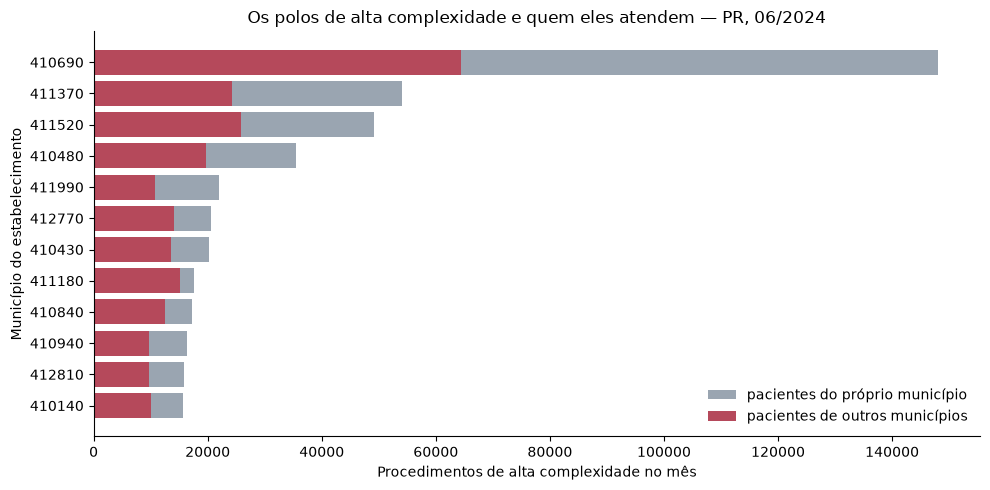

In [15]:
polos = con.execute(f"""
    SELECT PA_UFMUN AS municipio,
           count(*) AS procedimentos,
           sum(CASE WHEN PA_MUNPCN <> PA_UFMUN THEN 1 ELSE 0 END) AS de_fora,
           sum(TRY_CAST(PA_VALAPR AS DOUBLE)) AS valor
    FROM read_parquet('{principal}')
    WHERE PA_NIVCPL = '3' AND length(PA_MUNPCN) = 6
    GROUP BY 1 ORDER BY procedimentos DESC LIMIT 12
""").df().set_index("municipio")
polos["% de pacientes de fora"] = (
    polos["de_fora"] / polos["procedimentos"] * 100).round(1)

print("Os municípios que mais realizam alta complexidade")
print("(o código é o do IBGE com seis dígitos — 410690 é Curitiba)\n")
display(polos)

figura, eixo = plt.subplots(figsize=(10, 5))
ordenado = polos.sort_values("procedimentos")
eixo.barh(ordenado.index.astype(str), ordenado["procedimentos"], color="#9aa5b1",
          label="pacientes do próprio município")
eixo.barh(ordenado.index.astype(str), ordenado["de_fora"], color="#b5495b",
          label="pacientes de outros municípios")
eixo.set_xlabel("Procedimentos de alta complexidade no mês")
eixo.set_ylabel("Município do estabelecimento")
eixo.set_title(f"Os polos de alta complexidade e quem eles atendem — {UF}, {MES:02d}/{ANO}",
               fontsize=12)
eixo.legend(frameon=False)
eixo.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 8. Conferindo com a realidade

In [16]:
valor_total = por_grupo["Valor"].sum()
oncologia_valor = producao[producao["subgrupo"] == "0304"]["valor"].sum()
nefrologia_valor = producao[producao["subgrupo"] == "0305"]["valor"].sum()

print("Verificações de sanidade\n")
print(f"1. Alta complexidade acima de 40% do valor?   {alta['% do valor']}% "
      f"({'sim' if alta['% do valor'] > 40 else 'ATENÇÃO'})")
print(f"2. Atenção básica com valor próximo de zero?  "
      f"{complexidade.loc['Atenção básica', '% do valor']}% "
      f"({'sim' if complexidade.loc['Atenção básica', '% do valor'] < 1 else 'ATENÇÃO'})")
print(f"3. Oncologia e diálise somam mais de 20%?     "
      f"{(oncologia_valor + nefrologia_valor) / valor_total * 100:.1f}% "
      f"({'sim' if (oncologia_valor + nefrologia_valor) / valor_total > 0.2 else 'ATENÇÃO'})")
print(f"4. Diálise: registros compatíveis com a população?")
print(f"   {mil(pacientes_dialise['registros'])} registros no mês")
print("   O Brasil tem cerca de 800 pessoas em diálise por milhão de habitantes;")
print("   num estado de 11,8 milhões isso daria perto de 9 mil.")

Verificações de sanidade
1. Alta complexidade acima de 40% do valor?   50.8% (sim)
2. Atenção básica com valor próximo de zero?  0.0% (sim)
3. Oncologia e diálise somam mais de 20%?     26.7% (sim)
4. Diálise: registros compatíveis com a população?
   7.514 registros no mês
   O Brasil tem cerca de 800 pessoas em diálise por milhão de habitantes;
   num estado de 11,8 milhões isso daria perto de 9 mil.


## 9. Como adaptar

| Você quer | Mude isto |
|---|---|
| Outro estado ou mês | `UF`, `ANO`, `MES` |
| Um ano inteiro | rode em laço sobre os doze meses e some — não tente carregar tudo de uma vez |
| Detalhe da quimioterapia | use o grupo `AQ`, que traz CID, estadiamento e finalidade |
| Detalhe da diálise | grupo `ATD` ou `AN` |
| Por sexo, idade ou raça/cor | `PA_SEXO`, `PA_IDADE`, `PA_RACACOR` estão no arquivo |
| Por diagnóstico | `PA_CIDPRI` — use a função `capitulo_cid10` do notebook do SIM |
| Por estabelecimento | agrupe por `PA_CODUNI` e cruze com o CNES |

### O que vale levar

A leitura do **código SIGTAP** — dois dígitos para o grupo, quatro para o
subgrupo — classifica milhões de linhas sem tabela auxiliar.
E a ressalva do **valor zero na atenção básica**: ela não é barata, é paga por
fora do SIA.

---

*Exemplo do repositório [PySusNoCode-Exemplos](https://github.com/cartaproale/PySusNoCode-Exemplos).
Dados: SIA/SUS, via biblioteca [PySUS](https://github.com/AlertaDengue/PySUS).
Notebook executado de verdade antes de publicado.*